In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P3 - Sample ratio mismatch (SRM)

## 1. What goes wrong
The split is meant to be 50/50 but the treatment arm loses users (for example a page that crashes on slow phones, so they never get logged). The arms are no longer comparable and every number from the test is biased, usually in the treatment's favour.

## 2. Simulate

In [2]:
from abtest.pitfalls import srm
d = srm.srm_damage(drop_rates=(0, 0.01, 0.03, 0.05), n_sims=60, users_per_day=12_000)
d

,drop_rate,avg_fake_rel_lift,false_positive_rate,srm_detected
0,0.00,0.001462,0.083333,0.000000
1,0.01,0.006939,0.083333,0.066667
2,0.03,0.018522,0.083333,0.900000
3,0.05,0.030777,0.133333,1.000000


## 3. Quantify the damage

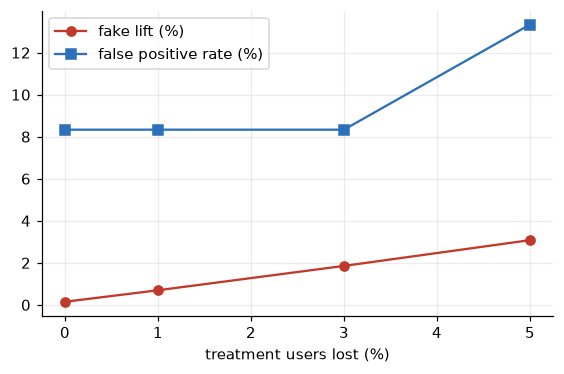

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(d.drop_rate * 100, d.avg_fake_rel_lift * 100, 'o-', color=BAD, label='fake lift (%)')
ax.plot(d.drop_rate * 100, d.false_positive_rate * 100, 's-', color=ACCENT, label='false positive rate (%)'); ax.legend(); ax.set(xlabel='treatment users lost (%)'); plt.show()

## 4. Detect

The chi-square sample-ratio check at p < 0.001. Detection depends on how many users you have, so measure it.

In [4]:
s = srm.srm_detection_by_size(users_per_day_grid=(1_000, 4_000, 8_000), n_sims=60)
print(s.to_string(index=False))

 users_per_day  srm_detected
          1000      0.000000
          4000      0.033333
          8000      0.166667


## 5. Fix

There is no statistical fix. The fix is to distrust the result, find the root cause (bots, redirects, crashes, logging bugs, filters applied after assignment) and rerun.

## 6. Verify the fix

_The fix is procedural; see the Detect section for how it is checked._

## So what
A small, invisible user loss produces a fake lift and inflates false positives. An SRM check is cheap and should run before anyone looks at the metric.